In [1]:
from models import VGG11_32, VDP_VGG11_32
from utils_vdp import gaussian_loss, dirichlet_loss
from layers import MySoftmax

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy

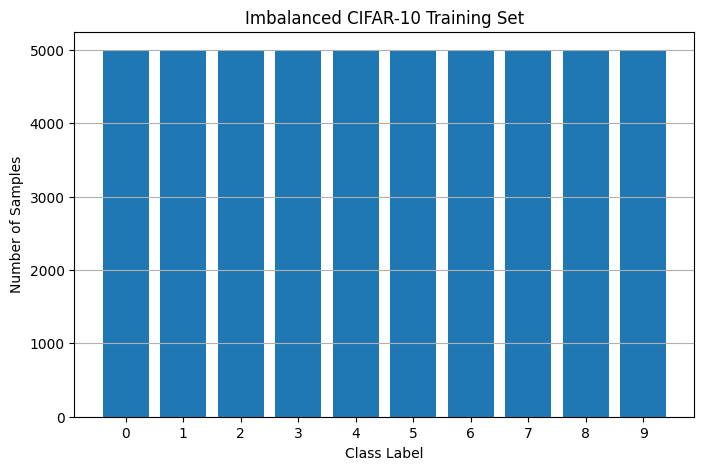

In [2]:
from torch.utils.data import Subset
from collections import defaultdict

def get_imbalanced_cifar10(imbalance_ratio=0.1):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    full_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    
    class_indices = defaultdict(list)
    for idx, (_, label) in enumerate(full_dataset):
        class_indices[label].append(idx)

    imbalanced_indices = []
    for c, indices in class_indices.items():
        n = len(indices)
        retain = int(n * (c+1) * imbalance_ratio)
        imbalanced_indices.extend(indices[:retain])

    imbalanced_dataset = Subset(full_dataset, imbalanced_indices)
    return imbalanced_dataset

trainset = get_imbalanced_cifar10(imbalance_ratio=0.1)
trainset =  torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                       transform=transforms.ToTensor())
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,
                                       transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

def plot_class_histogram(dataset, title="Class Distribution"):
    class_counts = np.zeros(10, dtype=int)
    for i in range(len(dataset)):
        _, label = dataset[i]
        class_counts[label] += 1

    plt.figure(figsize=(8, 5))
    plt.bar(np.arange(10), class_counts)
    plt.xlabel("Class Label")
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.xticks(np.arange(10))
    plt.grid(axis='y')
    plt.show()

# Call the function
plot_class_histogram(trainset, title="Imbalanced CIFAR-10 Training Set")

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG11_32(10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(40):
    model.train()
    running_loss, accuracy = 0.0, 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        accuracy += (outputs.argmax(dim=1) == labels).float().sum().item()
        running_loss += loss.item()
    
    print(f"[Epoch {epoch+1}] loss: {running_loss/len(trainloader):.3f}, acc = {accuracy /len(trainloader.dataset):.3f}")

[Epoch 1] loss: 1.904, acc = 0.266
[Epoch 2] loss: 1.396, acc = 0.481
[Epoch 3] loss: 1.122, acc = 0.594
[Epoch 4] loss: 0.959, acc = 0.660
[Epoch 5] loss: 0.815, acc = 0.712
[Epoch 6] loss: 0.701, acc = 0.754
[Epoch 7] loss: 0.607, acc = 0.789
[Epoch 8] loss: 0.514, acc = 0.822
[Epoch 9] loss: 0.438, acc = 0.848
[Epoch 10] loss: 0.362, acc = 0.874
[Epoch 11] loss: 0.290, acc = 0.898
[Epoch 12] loss: 0.239, acc = 0.919
[Epoch 13] loss: 0.198, acc = 0.933
[Epoch 14] loss: 0.167, acc = 0.942
[Epoch 15] loss: 0.147, acc = 0.949
[Epoch 16] loss: 0.126, acc = 0.956
[Epoch 17] loss: 0.127, acc = 0.957
[Epoch 18] loss: 0.108, acc = 0.963
[Epoch 19] loss: 0.105, acc = 0.964
[Epoch 20] loss: 0.096, acc = 0.967
[Epoch 21] loss: 0.086, acc = 0.971
[Epoch 22] loss: 0.084, acc = 0.972
[Epoch 23] loss: 0.087, acc = 0.971
[Epoch 24] loss: 0.084, acc = 0.973
[Epoch 25] loss: 0.071, acc = 0.976
[Epoch 26] loss: 0.072, acc = 0.977
[Epoch 27] loss: 0.077, acc = 0.976
[Epoch 28] loss: 0.069, acc = 0.978
[

In [4]:
# Train from scratch
EPOCHS = 40
kl_factor = 0.00001

model_dirichlet = VDP_VGG11_32(num_classes=10)
model_dirichlet(next(iter(testloader))[0])

optimizer = optim.Adam(list(model_dirichlet.parameters()), lr=0.0001)
model_dirichlet = model_dirichlet.to(device)

for epoch in range(EPOCHS):
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        mu, sigma, kl = model_dirichlet(images)
        mu, sigma = MySoftmax()(mu, sigma) 

        loss1 = dirichlet_loss(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum().item()
    running_loss /= len(trainloader)
    running_kl /= len(trainloader)
    accuracy /= len(trainloader.dataset)
    print(running_loss, running_kl, accuracy)

2.182271914104062 925.1922768205023 0.27844
2.0907853021646097 868.9182052417179 0.38956
2.027400864969434 864.3923268037684 0.46052
1.9776957461901028 867.4094111840134 0.51982
1.935793829695953 872.1407185039861 0.56902
1.9096908962635128 877.7487162324169 0.59802
1.8828014461585627 883.4829955430287 0.62882
1.8583912965281846 889.5575864357717 0.65862
1.8446282797762195 895.7767786674792 0.67494
1.8226157838426282 902.0575678598545 0.69952
1.8054120754037062 908.8524357242047 0.72028
1.7900174142759475 915.8694536057884 0.73878
1.7762978336085444 923.4103704193974 0.75464
1.7619543374346955 930.9340220887948 0.77064
1.7499520388405647 938.0864306203545 0.78474
1.7389473805342184 945.8437148774676 0.79752
1.724198824609332 953.4275985678748 0.81474
1.7134633795989445 960.7183833207621 0.82782
1.7070459505481184 968.0614608413423 0.83546
1.6980508416509994 975.5741094798993 0.84522
1.6853123909372199 982.3242146913963 0.86026
1.6779598363525117 988.7878954953245 0.86748
1.672759520428

Balanced Accuracy: 0.7455
Macro F1 Score: 0.74534284416316
              precision    recall  f1-score   support

           0       0.74      0.82      0.78      1000
           1       0.88      0.86      0.87      1000
           2       0.71      0.60      0.65      1000
           3       0.54      0.58      0.56      1000
           4       0.69      0.71      0.70      1000
           5       0.65      0.62      0.64      1000
           6       0.78      0.82      0.80      1000
           7       0.78      0.79      0.78      1000
           8       0.87      0.81      0.84      1000
           9       0.83      0.83      0.83      1000

    accuracy                           0.75     10000
   macro avg       0.75      0.75      0.75     10000
weighted avg       0.75      0.75      0.75     10000



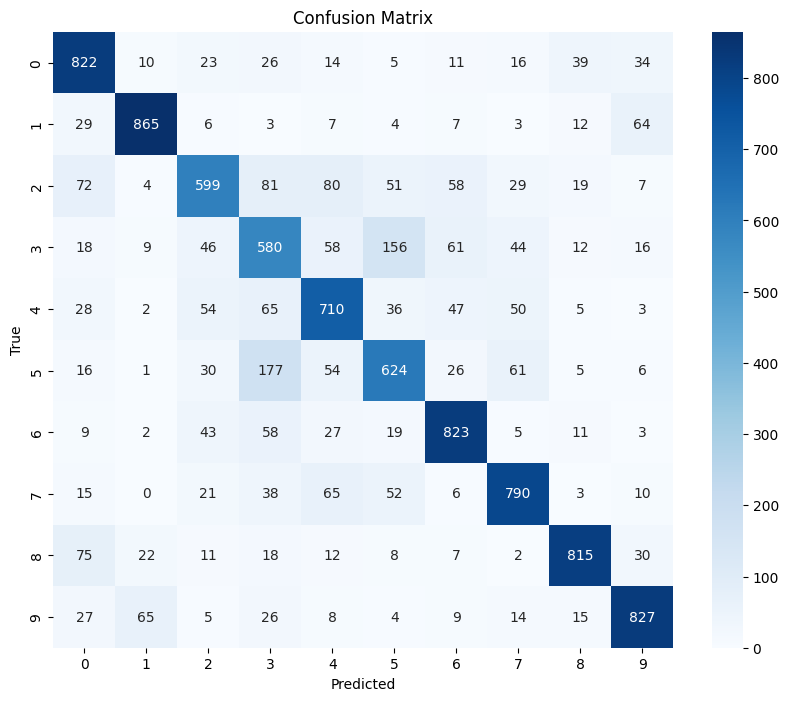

In [5]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

from sklearn.metrics import f1_score

print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
# G=mean, mcc sklearn imbalance

Balanced Accuracy: 0.7554
Macro F1 Score: 0.755336527244678
              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1000
           1       0.85      0.87      0.86      1000
           2       0.72      0.65      0.68      1000
           3       0.55      0.61      0.58      1000
           4       0.73      0.71      0.72      1000
           5       0.68      0.64      0.66      1000
           6       0.84      0.81      0.83      1000
           7       0.79      0.79      0.79      1000
           8       0.79      0.90      0.84      1000
           9       0.87      0.77      0.82      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



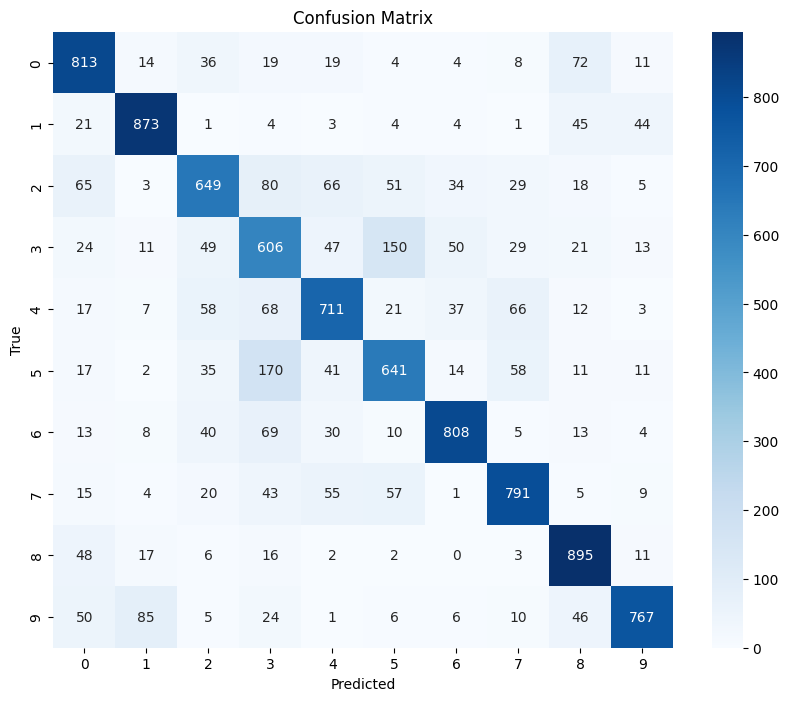

In [6]:
model.eval()
y_true = []
y_pred = []

for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    outputs,_, _ = model_dirichlet(images)
    _, preds = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

from sklearn.metrics import f1_score

print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [7]:
from collections import defaultdict
import torch.nn.functional as F

def fgsm_attack(model, images, labels, epsilon, vdp=True):
    images.requires_grad = True
    if vdp:
        outputs, _, _ = model(images)
    else:
        outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    data_grad = images.grad.data
    perturbed = images + epsilon * data_grad.sign()
    return torch.clamp(perturbed, 0, 1)

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.007, num_iter=10, vdp=True):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    ori_images = images.clone().detach()

    for _ in range(num_iter):
        images.requires_grad = True
        if vdp:
            outputs, _, _ = model(images)
        else:
            outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = images.grad.data

        # Update
        adv_images = images + alpha * grad.sign()
        # Project back into epsilon-ball
        eta = torch.clamp(adv_images - ori_images, min=-epsilon, max=epsilon)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach()

    return images

def evaluate_classwise_accuracy(model, dataloader, epsilon=0.0, attack_type="clean", alpha=0.007, num_iter=10, vdp=True):
    model.eval()
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)


    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        if attack_type == "fgsm":
            images = fgsm_attack(model, images, labels, epsilon, vdp=vdp)
        elif attack_type == "pgd":
            images = pgd_attack(model, images, labels, epsilon, alpha, num_iter, vdp=vdp)
        elif attack_type == "gaussian":
            images = images + epsilon * torch.ones_like(images)


        if vdp:
            outputs, _, _ = model(images)
        else:
            outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for label, pred in zip(labels, preds):
            total_per_class[label.item()] += 1
            if pred.item() == label.item():
                correct_per_class[label.item()] += 1

    acc = {c: correct_per_class[c] / total_per_class[c] for c in total_per_class}
    return acc


TypeError: max() received an invalid combination of arguments - got (tuple, int), but expected one of:
 * (Tensor input, *, Tensor out = None)
 * (Tensor input, Tensor other, *, Tensor out = None)
 * (Tensor input, int dim, bool keepdim = False, *, tuple of Tensors out = None)
 * (Tensor input, name dim, bool keepdim = False, *, tuple of Tensors out = None)


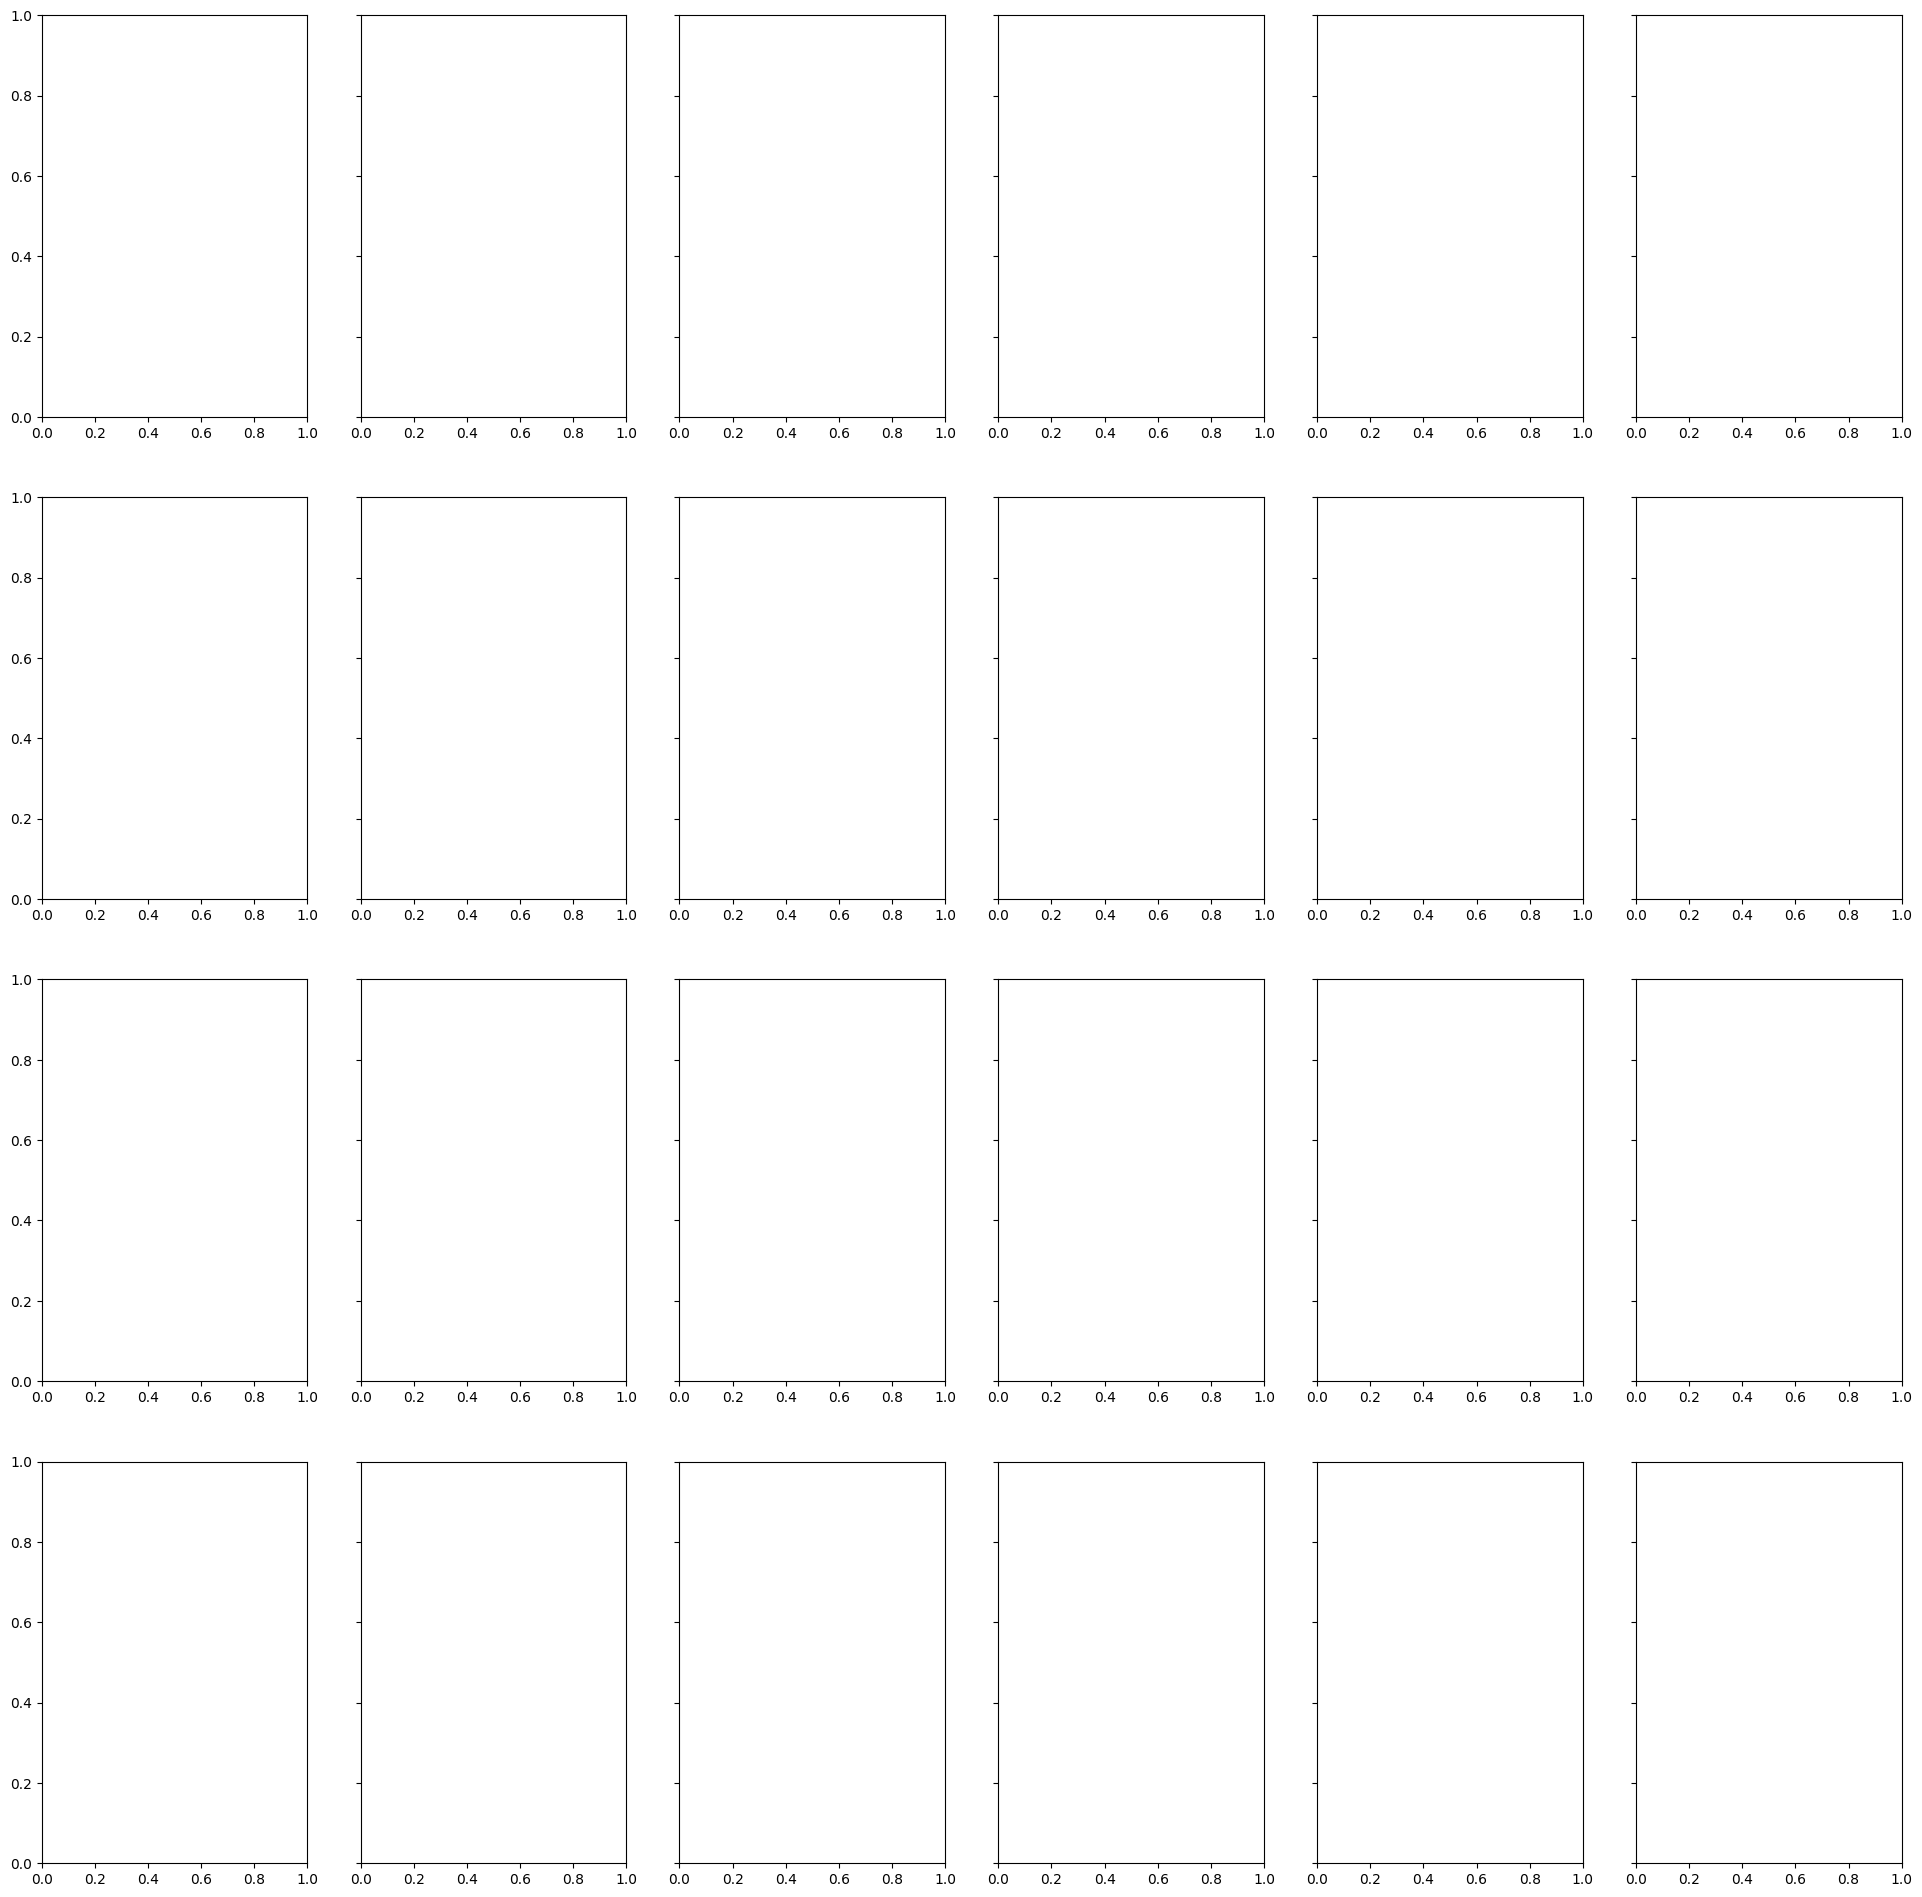

In [8]:
epsilons = [0.005, 0.01, 0.02, 0.03]
fig, axs = plt.subplots(len(epsilons), 6, figsize=(24,6*len(epsilons)), sharey=True)
eps = 1
for idx, epsilon in enumerate(epsilons):
    clean_acc_vdp = evaluate_classwise_accuracy(model_dirichlet, testloader, attack_type="clean", vdp=True)
    fgsm_acc_vdp = evaluate_classwise_accuracy(model_dirichlet, testloader, epsilon=epsilon, attack_type="fgsm", vdp=True)
    pgd_acc_vdp = evaluate_classwise_accuracy(model_dirichlet, testloader, epsilon=epsilon, attack_type="pgd", vdp=True)
    gaussian_acc_vdp = evaluate_classwise_accuracy(model_dirichlet, testloader, epsilon=epsilon, attack_type="gaussian", vdp=True)
    
    clean_acc = evaluate_classwise_accuracy(model, testloader, attack_type="clean", vdp=False)
    fgsm_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="fgsm", vdp=False)
    pgd_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="pgd", vdp=False)
    gaussian_acc = evaluate_classwise_accuracy(model_dirichlet, testloader, epsilon=epsilon, attack_type="gaussian", vdp=False)

        
    fgsm_drops_vdp = {c: (clean_acc_vdp[c] - fgsm_acc_vdp[c])/(clean_acc_vdp[c]+eps) for c in clean_acc_vdp}
    pgd_drops_vdp = {c: (clean_acc_vdp[c] - pgd_acc_vdp[c])/(clean_acc_vdp[c]+eps) for c in clean_acc_vdp}
    gaussian_drops_vdp = {c: (clean_acc_vdp[c] - gaussian_acc_vdp[c])/(clean_acc_vdp[c]+eps) for c in clean_acc_vdp}


    fgsm_drops = {c: (clean_acc[c] - fgsm_acc[c])/(clean_acc[c]+eps) for c in clean_acc}
    pgd_drops = {c: (clean_acc[c] - pgd_acc[c])/(clean_acc[c]+eps) for c in clean_acc}
    gaussian_drops = {c: (clean_acc[c] - gaussian_acc[c])/(clean_acc[c]+eps) for c in clean_acc}

    axs[idx, 0].bar(fgsm_drops_vdp.keys(), fgsm_drops_vdp.values())
    axs[idx, 0].set_xlabel("Class")
    axs[idx, 0].set_ylabel("Accuracy Drop")
    axs[idx, 0].hline(y=np.mean(fgsm_drops_vdp.values()))
    axs[idx, 0].set_title(f"VDP (FGSM ε={epsilon}) {np.mean(fgsm_drops_vdp.values())}")
    axs[idx, 0].grid(True)

    axs[idx, 1].bar(fgsm_drops.keys(), fgsm_drops.values())
    axs[idx, 1].set_xlabel("Class")
    axs[idx, 1].set_ylabel("Accuracy Drop")
    axs[idx, 1].hline(y=np.mean(fgsm_drops.values()))
    axs[idx, 1].set_title(f"(FGSM ε={epsilon}), {np.mean(fgsm_drops.values())}")
    axs[idx, 1].grid(True)

    axs[idx, 2].bar(pgd_drops_vdp.keys(), pgd_drops_vdp.values() )
    axs[idx, 2].set_xlabel("Class")
    axs[idx, 2].set_ylabel("Accuracy Drop")
    axs[idx, 2].hline(y=np.mean(pgd_drops_vdp.values()))
    axs[idx, 2].set_title(f"VDP (PGD ε={epsilon}) {np.mean(pgd_drops_vdp.values())}")
    axs[idx, 2].grid(True)

    axs[idx, 3].bar(pgd_drops.keys(), pgd_drops.values())
    axs[idx, 3].set_xlabel("Class")
    axs[idx, 3].set_ylabel("Accuracy Drop")
    axs[idx, 3].hline(y=np.mean(pgd_drops.values()))
    axs[idx, 3].set_title(f"(PGD ε={epsilon}), {np.mean(pgd_drops.values())}")
    axs[idx, 3].grid(True)

    axs[idx, 4].bar(gaussian_drops_vdp.keys(), gaussian_drops_vdp.values() )
    axs[idx, 4].set_xlabel("Class")
    axs[idx, 4].set_ylabel("Accuracy Drop")
    axs[idx, 4].hline(y=np.mean(pgd_drops_vdp.values()))
    axs[idx, 4].set_title(f"VDP (Gaussian ε={epsilon}) {np.mean(pgd_drops_vdp.values())}")
    axs[idx, 4].grid(True)

    axs[idx, 5].bar(gaussian_drops.keys(), gaussian_drops.values())
    axs[idx, 5].set_xlabel("Class")
    axs[idx, 5].set_ylabel("Accuracy Drop")
    axs[idx, 5].hline(y=np.mean(pgd_drops.values()))
    axs[idx, 5].set_title(f"(Gaussian ε={epsilon}), {np.mean(pgd_drops.values())}")
    axs[idx, 5].grid(True)

In [ ]:
def evaluate_classwise_accuracy_threshold(model, dataloader, drop_threshold=0.1, 
                                           alpha=0.007, num_iter=10, 
                                          eps_start=0.0, eps_end=0.5, eps_step=0.01, 
                                          vdp=True, device="cuda"):
    from collections import defaultdict
    import numpy as np

    def evaluate_accuracy(model, dataloader, attack_type=None, epsilon=0.0):
        model.eval()
        correct_per_class = defaultdict(int)
        total_per_class = defaultdict(int)
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            if attack_type == "fgsm":
                images = fgsm_attack(model, images, labels, epsilon, vdp=vdp)
            elif attack_type == "pgd":
                images = pgd_attack(model, images, labels, epsilon, alpha, num_iter, vdp=vdp)
            if vdp:
                outputs, _, _ = model(images)
            else:
                outputs = model(images)
            _, preds = torch.max(outputs, 1)
            for label, pred in zip(labels, preds):
                total_per_class[label.item()] += 1
                if pred.item() == label.item():
                    correct_per_class[label.item()] += 1
        return {c: correct_per_class[c] / total_per_class[c] for c in total_per_class}, total_per_class

    clean_acc, _ = evaluate_accuracy(model, dataloader, epsilon=0.0)
    min_eps_fgsm = {c: None for c in clean_acc}
    min_eps_pgd = {c: None for c in clean_acc}

    for eps in np.arange(eps_start, eps_end + eps_step, eps_step):
        if None in min_eps_fgsm.values():
            attacked_acc_fgsm, _ = evaluate_accuracy(model, dataloader, attack_type="fgsm", epsilon=eps)
        if None in min_eps_pgd.values():
            attacked_acc_pgd, _ = evaluate_accuracy(model, dataloader, attack_type="pgd", epsilon=eps)

        for c in clean_acc:
            if min_eps_fgsm[c] is None and attacked_acc_fgsm.get(c, 1.0) <= clean_acc[c] * (1 - drop_threshold):
                min_eps_fgsm[c] = eps
            if min_eps_pgd[c] is None and attacked_acc_pgd.get(c, 1.0) <= clean_acc[c] * (1 - drop_threshold):
                min_eps_pgd[c] = eps

    return min_eps_fgsm, min_eps_pgd, clean_acc

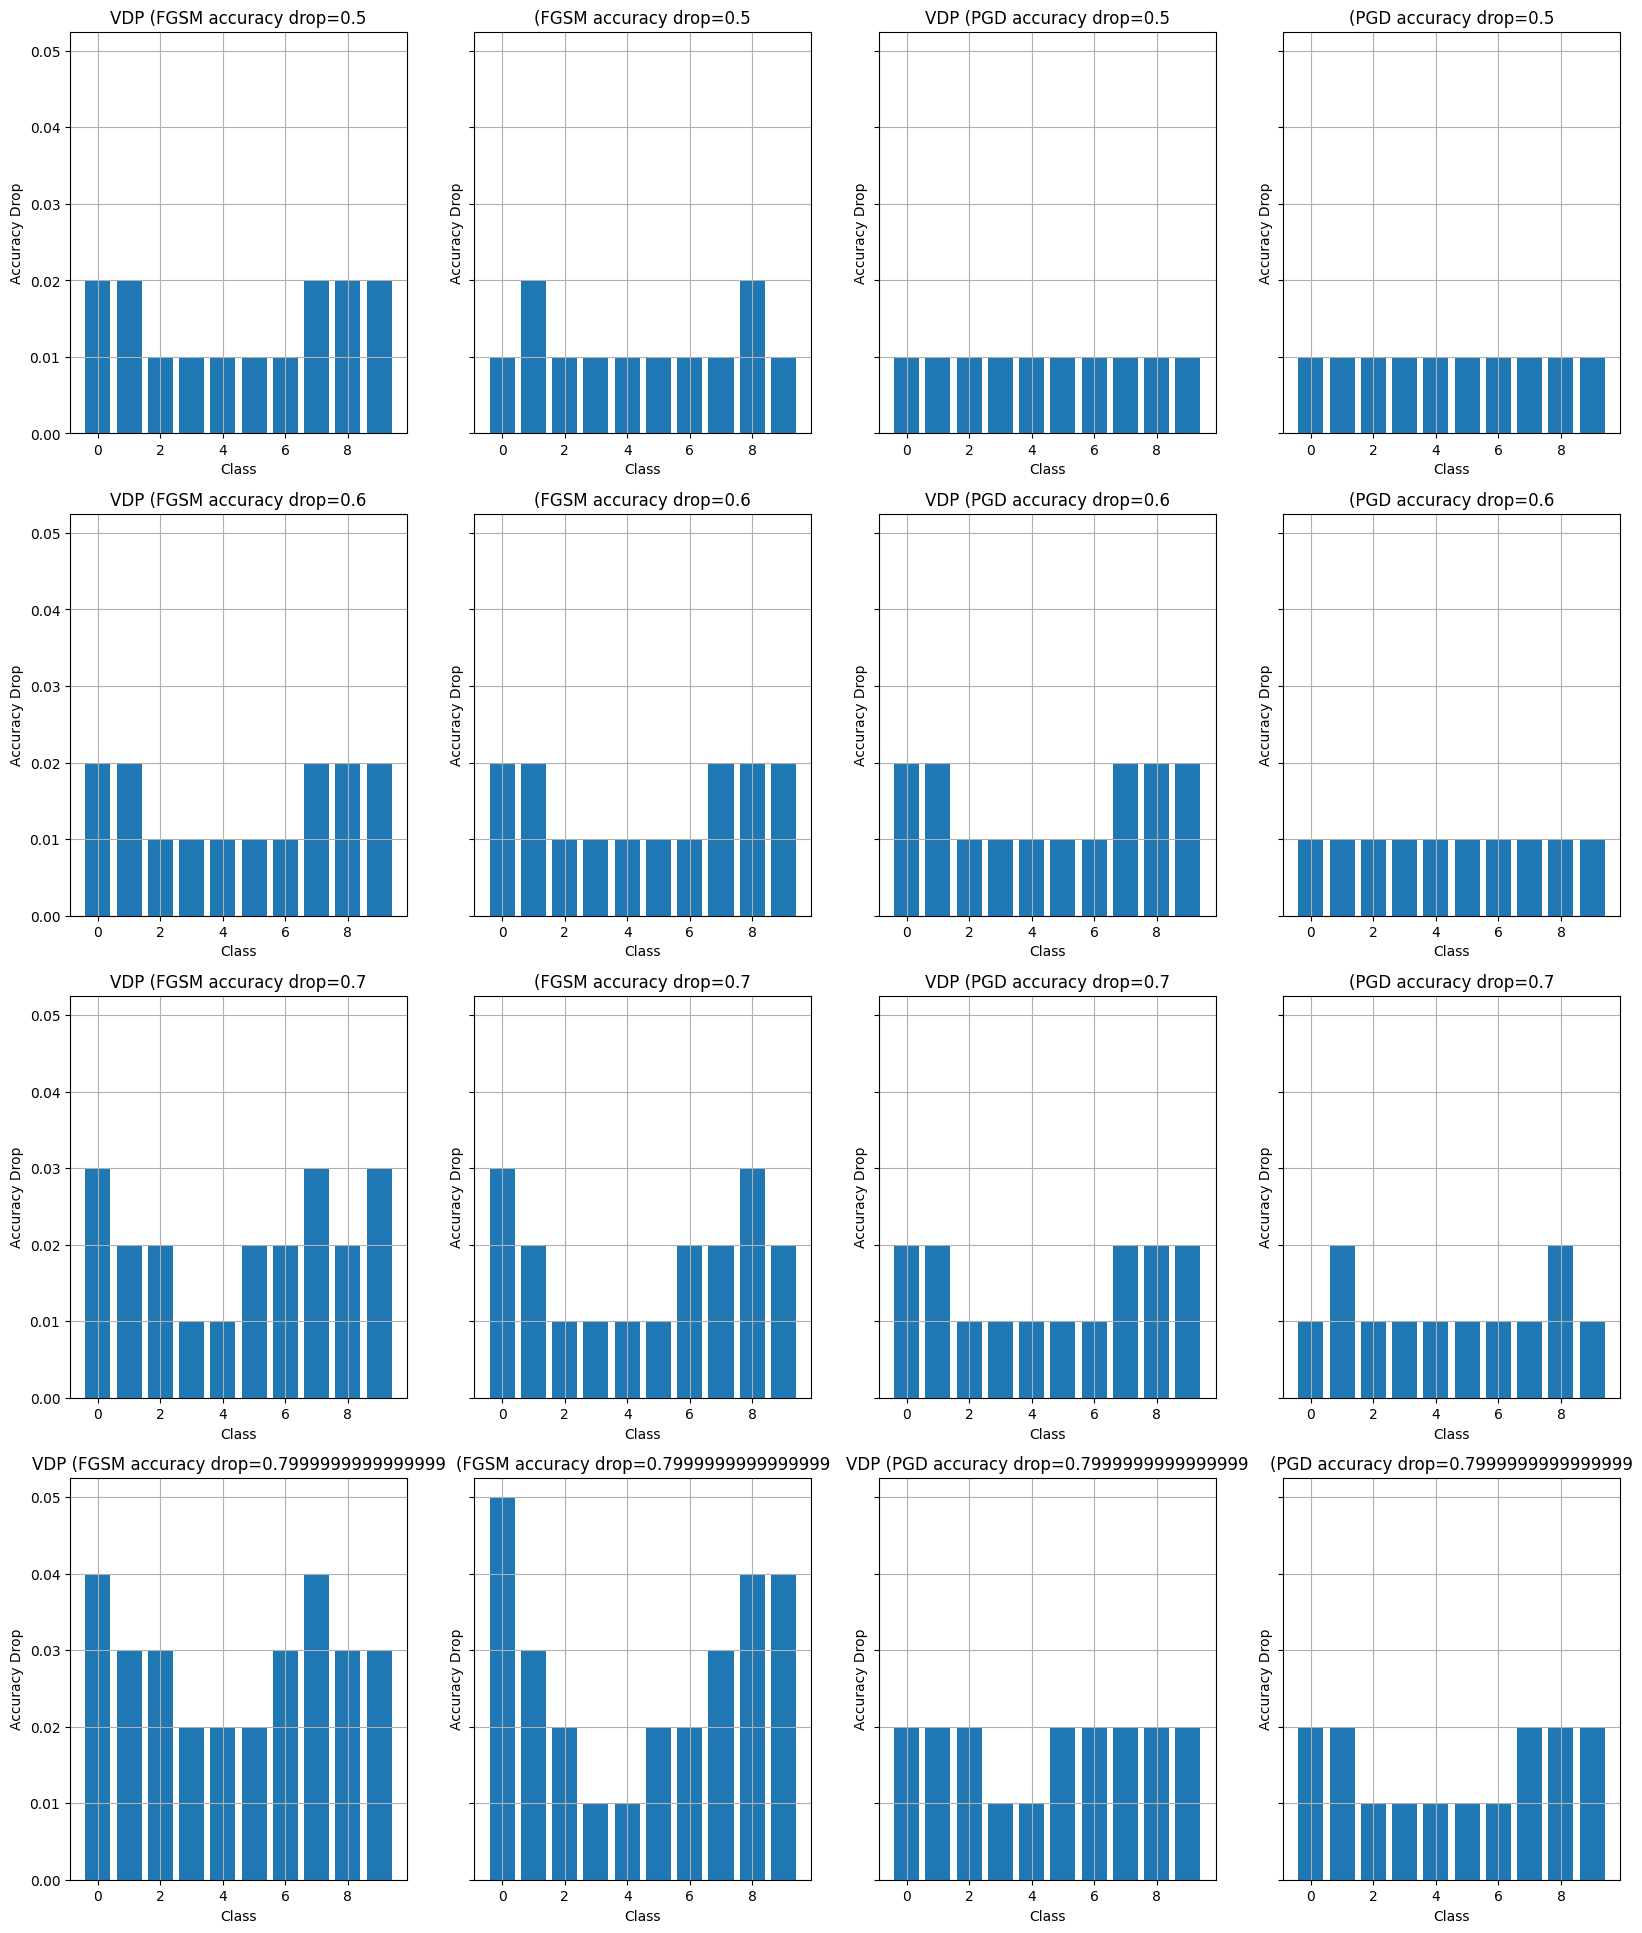

In [ ]:
ratios = np.arange(0.5, 0.9, step=0.1)
fig, axs = plt.subplots(len(ratios), 4, figsize=(20,6*len(epsilons)), sharey=True)
eps = 1
for idx, drop_ratio in enumerate(ratios):
    min_fgsm_vdp, min_pgd_vdp, clean_acc_vdp = evaluate_classwise_accuracy_threshold(
        model_dirichlet, testloader, drop_threshold=drop_ratio, vdp=True)

    min_fgsm, min_pgd, clean_acc = evaluate_classwise_accuracy_threshold(
        model, testloader, drop_threshold=drop_ratio, vdp=False)

    axs[idx, 0].bar(min_fgsm_vdp.keys(), min_fgsm_vdp.values())
    axs[idx, 0].set_xlabel("Class")
    axs[idx, 0].set_ylabel("Accuracy Drop")
    axs[idx, 0].set_title(f"VDP (FGSM accuracy drop={drop_ratio:.2f}")
    axs[idx, 0].grid(True)

    axs[idx, 1].bar(min_fgsm.keys(), min_fgsm.values())
    axs[idx, 1].set_xlabel("Class")
    axs[idx, 1].set_ylabel("Accuracy Drop")
    axs[idx, 1].set_title(f"(FGSM accuracy drop={drop_ratio:.2f}")
    axs[idx, 1].grid(True)

    axs[idx, 2].bar(min_pgd_vdp.keys(), min_pgd_vdp.values())
    axs[idx, 2].set_xlabel("Class")
    axs[idx, 2].set_ylabel("Accuracy Drop")
    axs[idx, 2].set_title(f"VDP (PGD accuracy drop={drop_ratio:.2f}")
    axs[idx, 2].grid(True)

    axs[idx, 3].bar(min_pgd.keys(), min_pgd.values())
    axs[idx, 3].set_xlabel("Class")
    axs[idx, 3].set_ylabel("Accuracy Drop")
    axs[idx, 3].set_title(f"(PGD accuracy drop={drop_ratio:.2f}")
    axs[idx, 3].grid(True)

# Train only sigma

In [ ]:
# Train only sigma
EPOCHS = 10
kl_factor = 0.00001
from layers import MySoftmax

model_vdp_finetune = VDP_VGG11_32(num_classes=10)
model_vdp_finetune(next(iter(testloader))[0])
model_vdp_finetune.load_weights(model)

optimizer = optim.Adam(list(model_vdp_finetune.parameters())[1::2], lr=0.0001)
model_vdp_finetune = model_vdp_finetune.to(device)

for epoch in range(EPOCHS):
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        mu, sigma, kl = model_vdp_finetune(images)
        mu, sigma = MySoftmax()(mu, sigma) 

        loss1 = gaussian_loss(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum()
    running_loss /= len(trainloader)
    running_kl /= len(trainloader)
    accuracy /= len(trainloader.dataset)
    print(running_loss)

Parameters assigned successfully.
-0.10391739984084894
-0.10399377265492
-0.10401894055955761
-0.10404239176540403


In [ ]:
# Train only sigma
EPOCHS = 10
kl_factor = 0.00001
from layers import MySoftmax

model_vdp_finetune_dirichlet = VDP_VGG11_32(num_classes=10)
model_vdp_finetune_dirichlet(next(iter(testloader))[0])
model_vdp_finetune_dirichlet.load_weights(model)

optimizer = optim.Adam(list(model_vdp_finetune_dirichlet.parameters())[1::2], lr=0.0001)
model_vdp_finetune_dirichlet = model_vdp_finetune_dirichlet.to(device)

for epoch in range(EPOCHS):
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        mu, sigma, kl = model_vdp_finetune_dirichlet(images)
        mu, sigma = MySoftmax()(mu, sigma) 

        loss1 = dirichlet_loss(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum()
    running_loss /= len(trainloader)
    running_kl /= len(trainloader)
    accuracy /= len(trainloader.dataset)
    print(running_loss)

In [ ]:
import evaluate_models
ood = torchvision.datasets.SVHN(root='./data', download=True, transform=transforms.ToTensor())
oodloader = torch.utils.data.DataLoader(ood, batch_size=128, shuffle=False, num_workers=2)


results, results_vdp, (ece, ece_vdp, brier, brier_vdp), (gaussian_noise, gaussian_noise_vdp) = evaluate_models.compare_two_models(model, model_vdp_finetune, testloader, oodloader, 'cuda')
results_dirichlet, results_vdp_dirichlet, (ece, ece_vdp, brier, brier_vdp), (gaussian_noise, gaussian_noise_vdp) = evaluate_models.compare_two_models(model, model_vdp_finetune, testloader, oodloader, 'cuda')


Evaluating models
Evaluating VDP model
Evaluating calibration
Evaluating Gaussian noise
{'max_output_auroc': np.float64(0.5123008026536714), 'max_output_aupr': np.float64(0.15104799514345418), 'max_output_fpr95': np.float64(0.9385724231131496), 'entropy_auroc': np.float64(0.5297351065427195), 'entropy_aupr': np.float64(0.1689958729554438), 'entropy_fpr95': np.float64(0.9447970842376838)} {'max_output_auroc': np.float64(0.5312542173444176), 'max_output_aupr': np.float64(0.17093034971329996), 'max_output_fpr95': np.float64(0.9452612037074956), 'mean_output_sigma_auroc': np.float64(0.5232542794545232), 'mean_output_sigma_aupr': np.float64(0.25988618561400256), 'mean_output_sigma_fpr95': np.float64(0.947390693039573), 'max_output_sigma_auroc': np.float64(0.5256582333428887), 'max_output_sigma_aupr': np.float64(0.24171664815561125), 'max_output_sigma_fpr95': np.float64(0.9496293869527827), 'entropy_auroc': np.float64(0.5297350321470985), 'entropy_aupr': np.float64(0.1689959556121463), 'entr

In [ ]:
import numpy as np
import pandas as pd

metrics = ['auroc', 'aupr', 'fpr95']
vdp_by_metric = {m: [] for m in metrics}

for k, v in results_vdp.items():
    if k.endswith(tuple(metrics)):
        for metric in metrics:
            if k.endswith(metric):
                vdp_by_metric[metric].append((k.replace(f"_{metric}", ""), v))
                break

# Sort and select top 2 for each metric
summary = []

for metric in metrics:
    entries = vdp_by_metric[metric]
    if metric == 'fpr95':
        top2 = sorted(entries, key=lambda x: x[1])[:2]  # lower is better
    else:
        top2 = sorted(entries, key=lambda x: x[1], reverse=True)[:2]  # higher is better

    row = {
        'Metric': metric.upper(),
        'Top 1 (VDP)': f'{top2[0][0]}: {top2[0][1]:.4f}',
        'Top 2 (VDP)': f'{top2[1][0]}: {top2[1][1]:.4f}',
        'Baseline max_output': f'{results[f"max_output_{metric}"]:.4f}',
        'Baseline entropy': f'{results[f"entropy_{metric}"]:.4f}',
    }
    summary.append(row)

# Display as DataFrame
df = pd.DataFrame(summary)
print(df.to_markdown(index=False))


| Metric   | Top 1 (VDP)               | Top 2 (VDP)              |   Baseline max_output |   Baseline entropy |
|:---------|:--------------------------|:-------------------------|----------------------:|-------------------:|
| AUROC    | max_output: 0.5313        | epistemic_mc: 0.5304     |                0.5123 |             0.5297 |
| AUPR     | mean_output_sigma: 0.2599 | max_output_sigma: 0.2417 |                0.151  |             0.169  |
| FPR95    | entropy: 0.9448           | max_output: 0.9453       |                0.9386 |             0.9448 |


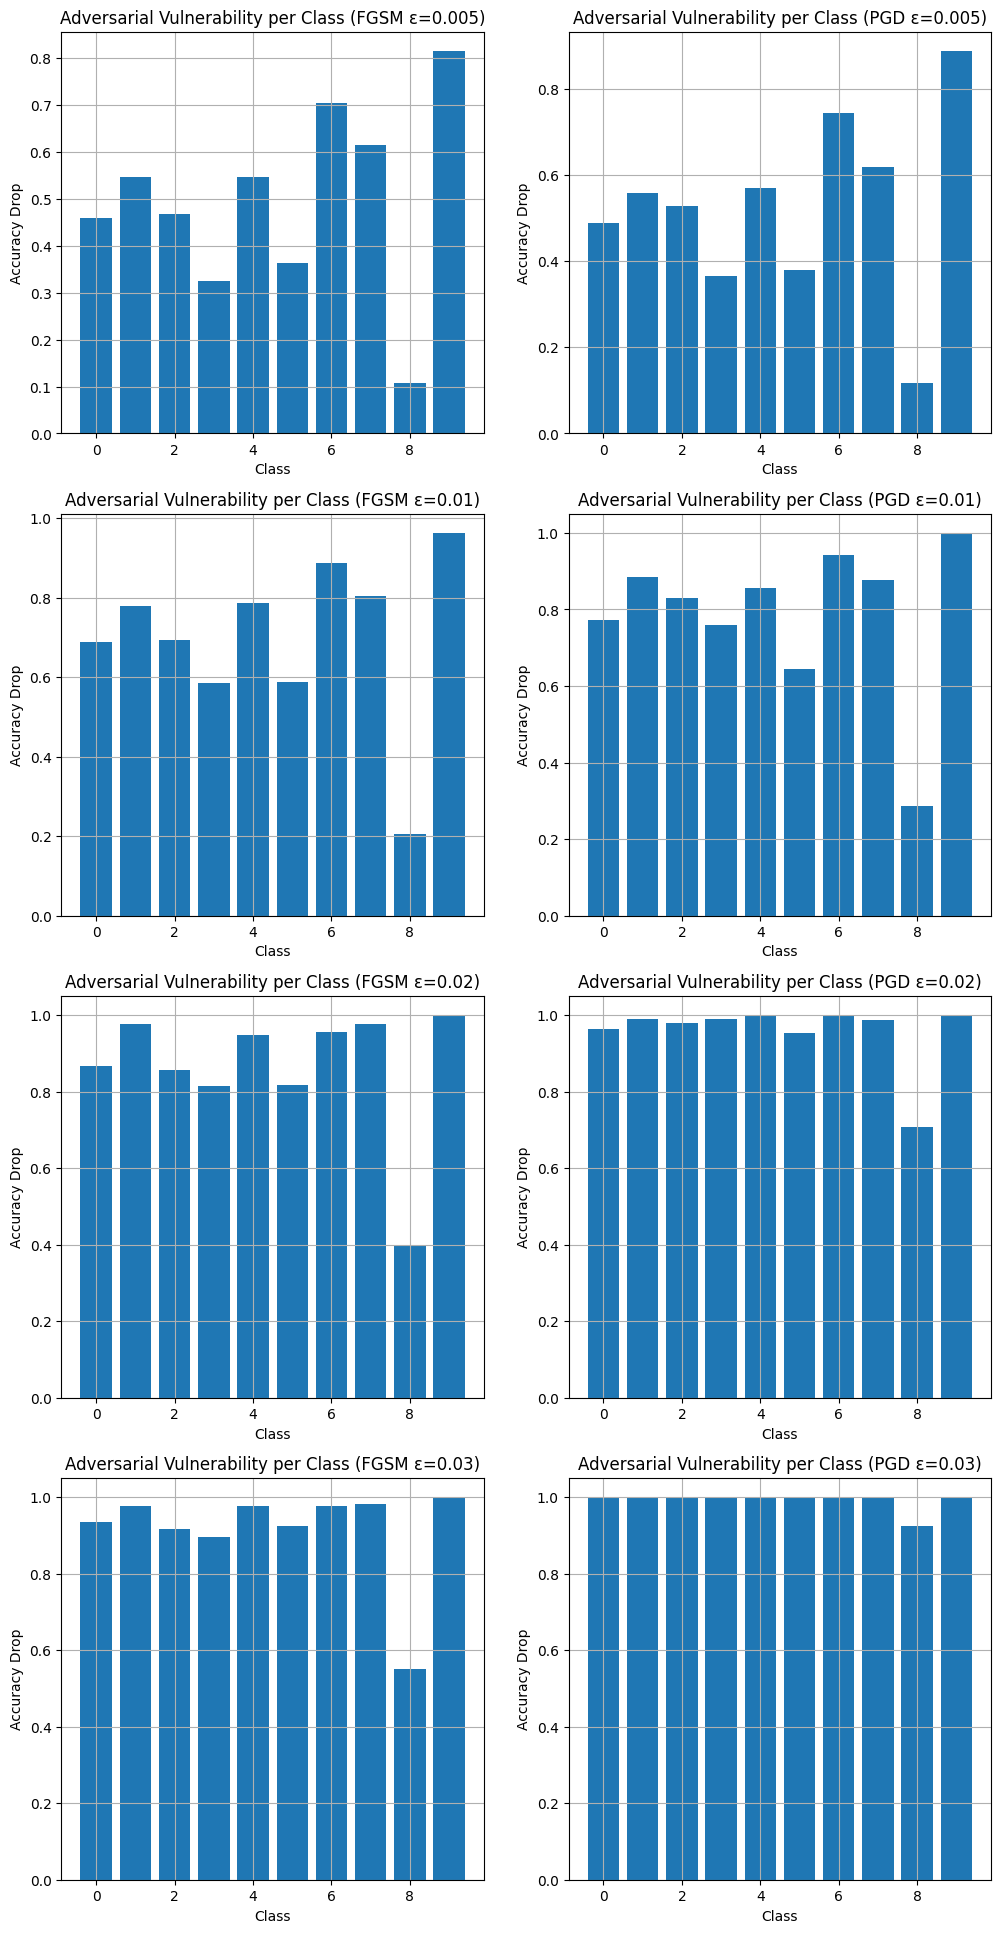

In [18]:
epsilons = [0.005, 0.01, 0.02, 0.03]
fig, axs = plt.subplots(len(epsilons), 2, figsize=(12,6*len(epsilons)))

for idx, epsilon in enumerate(epsilons):
    clean_acc = evaluate_classwise_accuracy(model, testloader, attack_type="clean", vdp=False)
    fgsm_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="fgsm", vdp=False)
    pgd_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="pgd", vdp=False)


    fgsm_drops = {c: (clean_acc[c] - fgsm_acc[c])/(clean_acc[c]+1e-9) for c in clean_acc}
    pgd_drops = {c: (clean_acc[c] - pgd_acc[c])/(clean_acc[c]+1e-9) for c in clean_acc}


    axs[idx, 0].bar(fgsm_drops.keys(), fgsm_drops.values())
    axs[idx, 0].set_xlabel("Class")
    axs[idx, 0].set_ylabel("Accuracy Drop")
    axs[idx, 0].set_title(f"Adversarial Vulnerability per Class (FGSM ε={epsilon})")
    axs[idx, 0].grid(True)

    axs[idx, 1].bar(pgd_drops.keys(), pgd_drops.values())
    axs[idx, 1].set_xlabel("Class")
    axs[idx, 1].set_ylabel("Accuracy Drop")
    axs[idx, 1].set_title(f"Adversarial Vulnerability per Class (PGD ε={epsilon})")
    axs[idx, 1].grid(True)

